In [2]:
# Importações
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from ucimlrepo import fetch_ucirepo

In [3]:
# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X = wine.data.features
y = wine.data.targets

print("Primeiras 5 linhas dos dados:")
print(X.head())

print("\nPrimeiras 5 linhas dos rótulos:")
print(y.head())

# features
print("Shape dos dados:", X.shape)
# class
print("Shape dos rótulos:", y.shape) 

Primeiras 5 linhas dos dados:
   Alcohol  Malicacid   Ash  Alcalinity_of_ash  Magnesium  Total_phenols  \
0    14.23       1.71  2.43               15.6        127           2.80   
1    13.20       1.78  2.14               11.2        100           2.65   
2    13.16       2.36  2.67               18.6        101           2.80   
3    14.37       1.95  2.50               16.8        113           3.85   
4    13.24       2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid_phenols  Proanthocyanins  Color_intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   0D280_0D315_of_diluted_wines  Proli

In [ ]:
# Média e desvio padrão

print("Média das features:")
print(X.mean())

print("\nDesvio padrão:")
print(X.std())

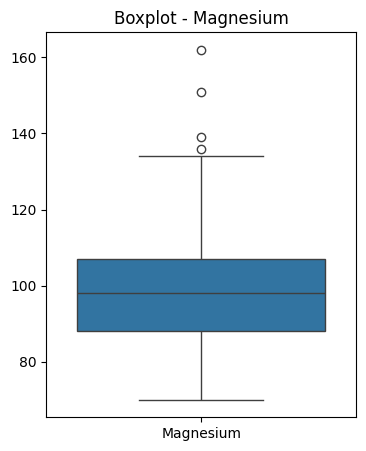

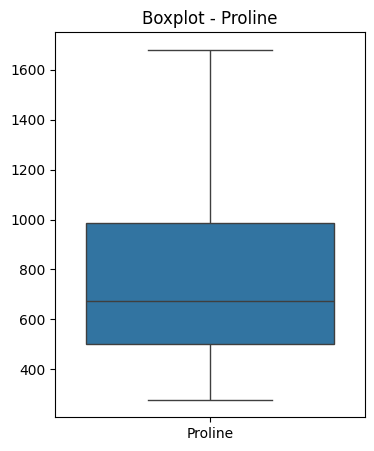

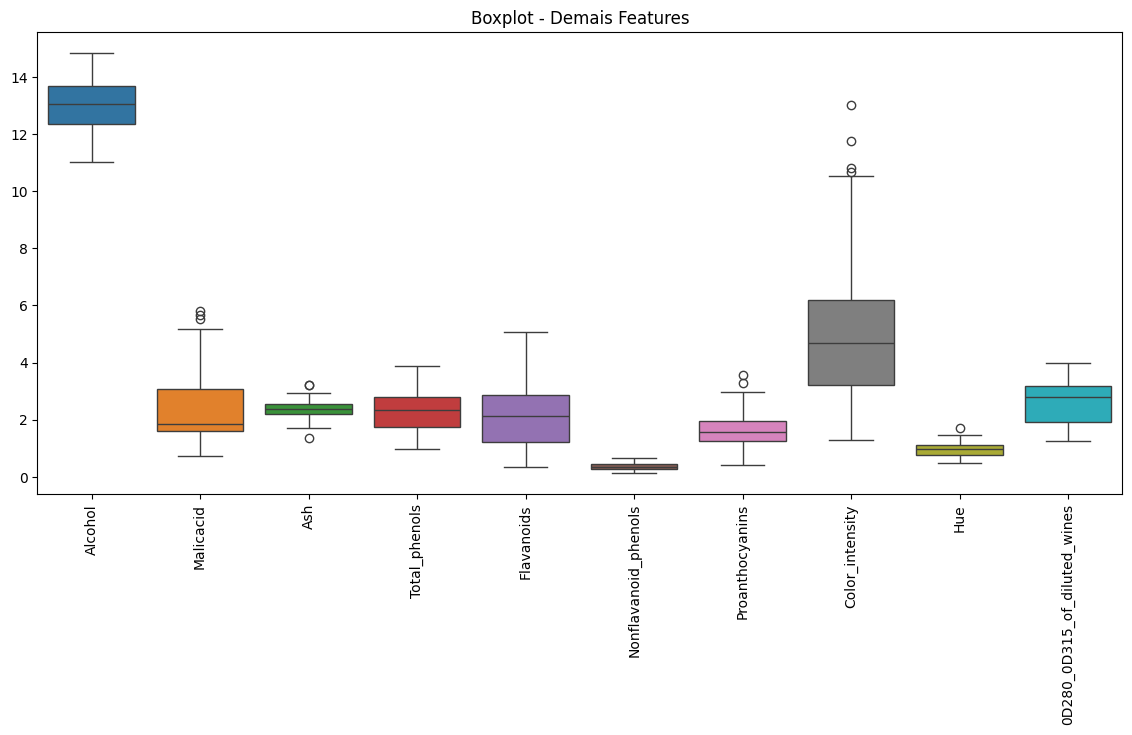

In [ ]:
# Boxplot

X_magnesium = X[['Magnesium']]
X_proline = X[['Proline']]
X_a = X.drop(columns=['Magnesium', 'Proline'])

# Magnesium
plt.figure(figsize=(4,5))
sns.boxplot(data=X_magnesium)
plt.title("Boxplot - Magnesium")
plt.show()

# Proline
plt.figure(figsize=(4,5))
sns.boxplot(data=X_proline)
plt.title("Boxplot - Proline")
plt.show()

# Demais features
plt.figure(figsize=(14,6))
sns.boxplot(data=X_a)
plt.xticks(rotation=90)
plt.title("Boxplot - Demais Features")
plt.show()



In [ ]:
# Normalização

# normalização usando StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# transformar em dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# dados normalizados
print(X_scaled.head())

# dados nao normalizados para comparação
print(X.head())

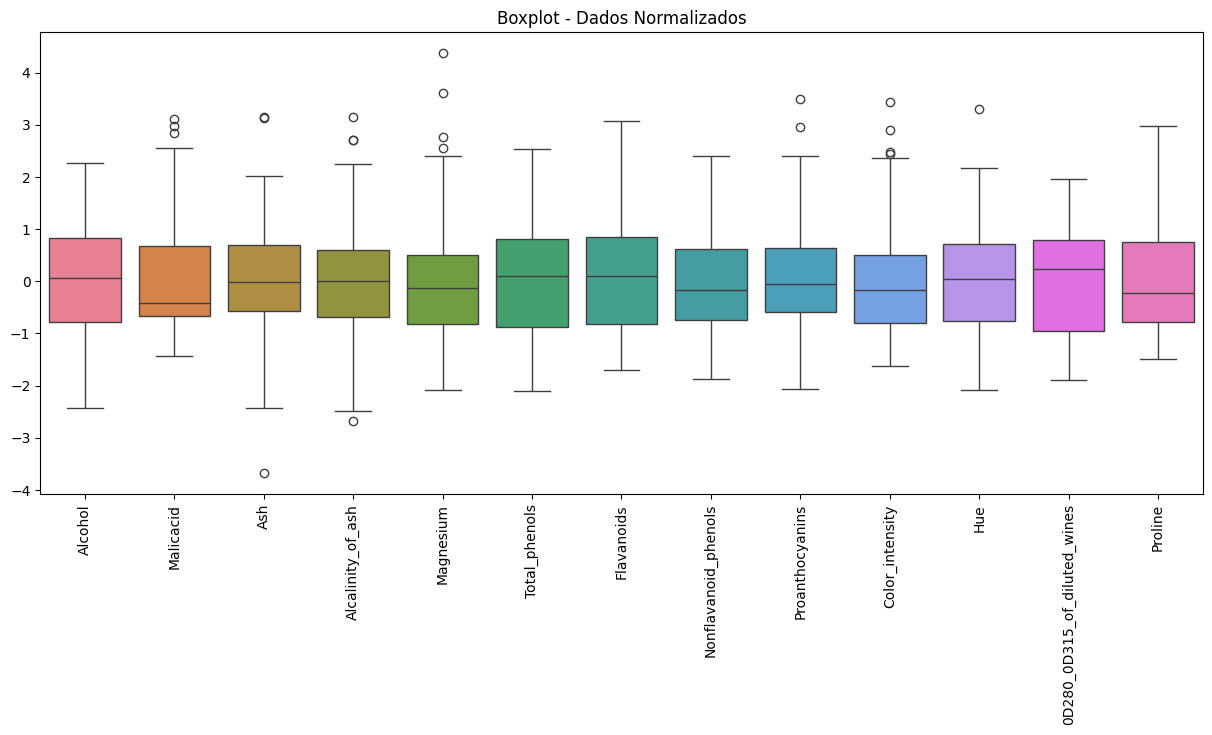

In [7]:
# Boxplot normalizado

plt.figure(figsize=(15,6))

sns.boxplot(data=X_scaled)

plt.xticks(rotation=90)

plt.title("Boxplot - Dados Normalizados")
plt.show()

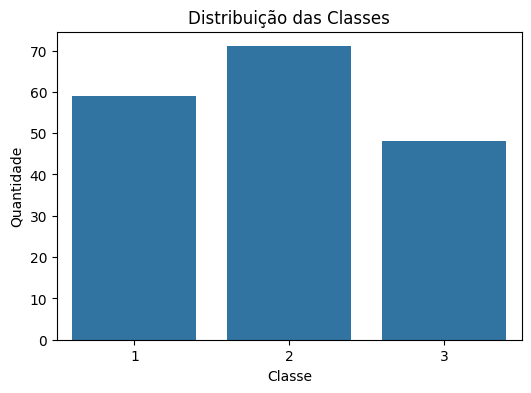

In [8]:
# Distribuição das classes

plt.figure(figsize=(6,4))

sns.countplot(x=y["class"])

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

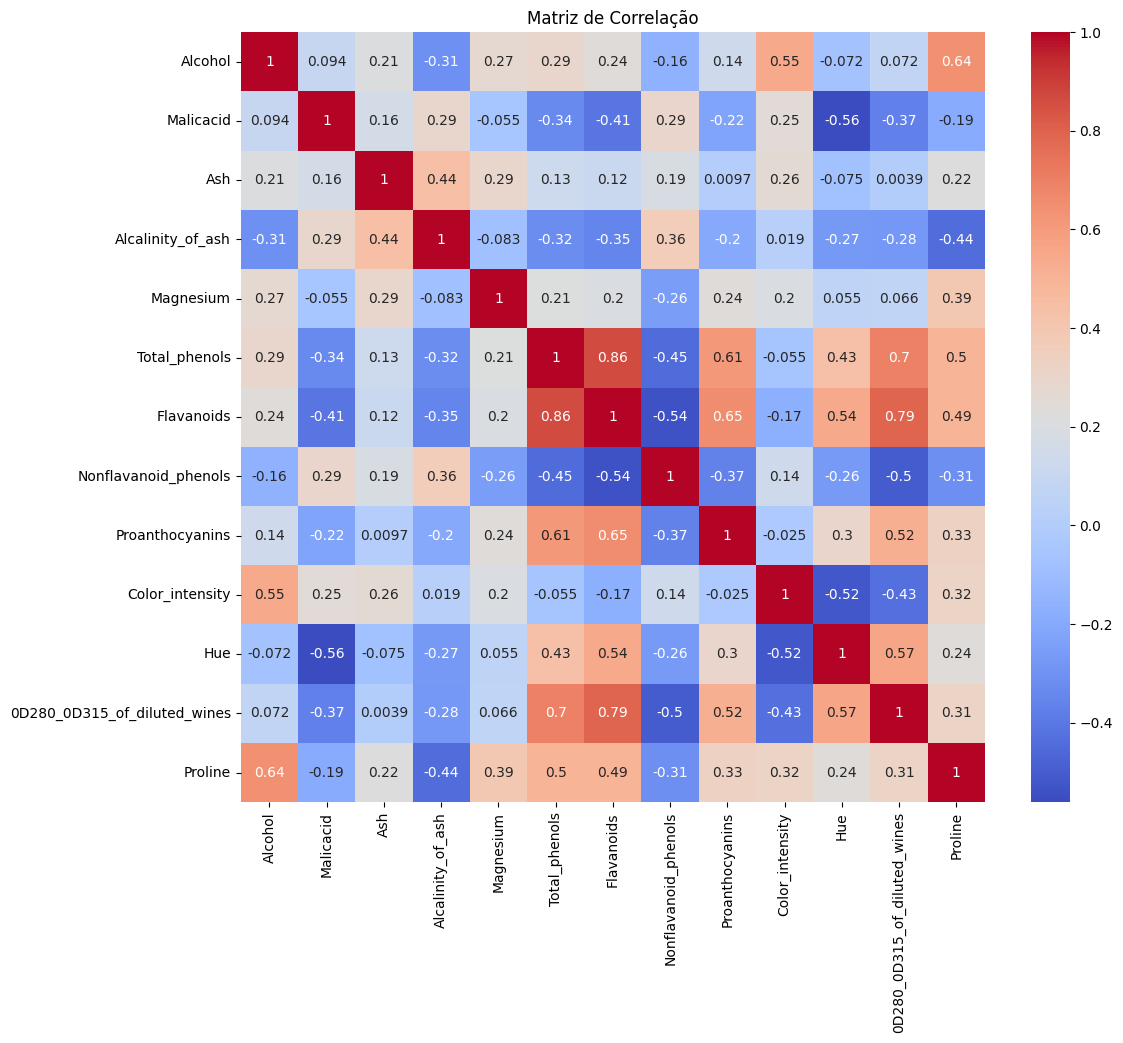

In [9]:
# Matriz de correlação

# calcular correlação
corr = X.corr()

# plotar
plt.figure(figsize=(12,10))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de Correlação")

plt.show()

In [10]:
# Features mais relacionadas

corr_pairs = corr.unstack()

# remover correlação consigo mesmo
corr_pairs = corr_pairs[corr_pairs != 1]

# ordenar
corr_sorted = corr_pairs.sort_values(ascending=False)

print(corr_sorted.head(10))

Total_phenols                 Flavanoids                      0.864564
Flavanoids                    Total_phenols                   0.864564
0D280_0D315_of_diluted_wines  Flavanoids                      0.787194
Flavanoids                    0D280_0D315_of_diluted_wines    0.787194
Total_phenols                 0D280_0D315_of_diluted_wines    0.699949
0D280_0D315_of_diluted_wines  Total_phenols                   0.699949
Proanthocyanins               Flavanoids                      0.652692
Flavanoids                    Proanthocyanins                 0.652692
Alcohol                       Proline                         0.643720
Proline                       Alcohol                         0.643720
dtype: float64


In [11]:
# PCA 2D

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# dataframe PCA
pca_df = pd.DataFrame()

pca_df["PCA1"] = X_pca[:,0]
pca_df["PCA2"] = X_pca[:,1]
pca_df["Classe"] = y["class"]

print(pca_df.head())

       PCA1      PCA2  Classe
0  3.316751  1.443463       1
1  2.209465 -0.333393       1
2  2.516740  1.031151       1
3  3.757066  2.756372       1
4  1.008908  0.869831       1


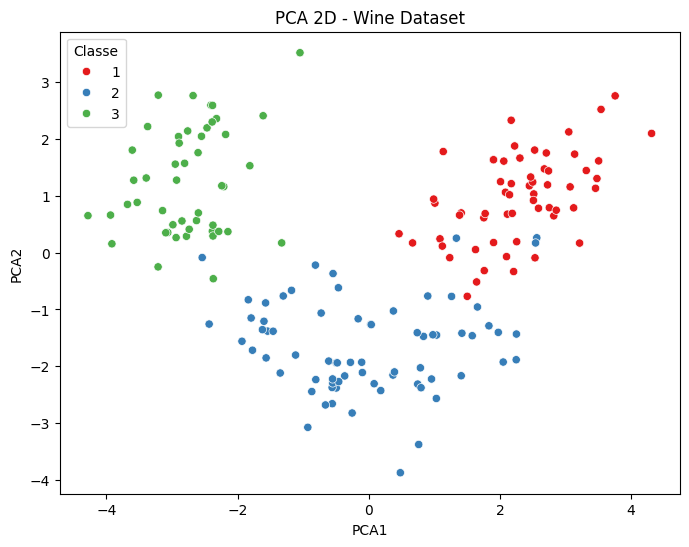

In [12]:
# Plot PCA

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Classe",
    palette="Set1"
)

plt.title("PCA 2D - Wine Dataset")

plt.show()